Francisco Benita, 2026

In [1]:
# @title Step 1: Install Libraries
# In Google Colab or local environments, install necessary libraries for geospatial analysis
!pip install -q geopandas
!pip install -q mapclassify
!pip install -q requests
!pip install -q rtree
!pip install -q networkx

In [2]:
# @title Step 2: Download the Geospatial Data

import requests
from pathlib import Path

# Dictionary of data names and their download URLs
## Replace the urls by the gpkg files provided in Zenodo
urls = {
    "boundary": "https://www.dropbox.com/scl/fi/lu6b5r7gseg1dlxdvy6z6/Phnom_Penh_boundary.gpkg?rlkey=e9o9k04rjr1xebtduqlrsu7xj&st=e09ydi28&dl=1",
    "pedestrian_network": "https://www.dropbox.com/scl/fi/xu6n622tgqm9vry8iuzkt/Phnom_Penh_pedestrian_network.gpkg?rlkey=hs1t3zlpvbh9nn06rglkf0lko&st=ul7gx1m6&dl=1",
    "population_count": "https://www.dropbox.com/scl/fi/7c2vav9dg4fb7yn9vl0lw/Phnom_Penh_Pop_counts.gpkg?rlkey=3nytgtueqfmfdoaysik11xft6&st=j5v8jont&dl=1",
    "poi_food": "https://www.dropbox.com/scl/fi/2u7pa6q6qfylt1yvxpdx8/Phnom_Penh_food_amenities.gpkg?rlkey=40b4vqtp83wlkwo5xzejygks2&st=l2tbsl6d&dl=1",
    "poi_healthcare": "https://www.dropbox.com/scl/fi/0ef0c7aqc01aylflnepn7/Phnom_Penh_healthcare_amenities.gpkg?rlkey=0gdndzd32ju1bvha2xtqyh0jw&st=3s7r7dsx&dl=1",
    "poi_educational": "https://www.dropbox.com/scl/fi/sh7692yka0kyb9kl7wno7/Phnom_Penh_education_amenities.gpkg?rlkey=qjyihbhti4f6y7xnl7uvqmwzx&st=36x1spi2&dl=1",
    "poi_leisure": "https://www.dropbox.com/scl/fi/kny6fmf2df91atvwpbl5w/Phnom_Penh_leisure_amenities.gpkg?rlkey=zfimv1oe76vutperou0g4oo1w&st=6o3gblp5&dl=1",
    "buildings": "https://www.dropbox.com/scl/fi/e395ta2qrcs2mdlohpdi4/Phnom_Penh__buildings.gpkg?rlkey=igq2r3yoek7ch0fgkxkmigtr2&st=at5r56yo&dl=1",
    "elevation": "https://www.dropbox.com/scl/fi/1jrr7eg8fl7pgk4dtrjw4/Phnom_Penh_elevation.gpkg?rlkey=ukusxwdhu2ed6xxa1my74hvz1&st=8fnyzyhv&dl=1",
    "grid": "https://www.dropbox.com/scl/fi/0jtpo65zarx67a24h01bo/Phnom_Penh_1200m_hex_grid.gpkg?rlkey=kmvxjtg92byh0n4g00engzked&st=5z6txo0m&dl=1",
    "centroids": "https://www.dropbox.com/scl/fi/sqjvenusga95mkx0rsxsv/Phnom_Penh_1200m_centroids.gpkg?rlkey=mfztswpv0xb8vyzk4ndscmq5t&st=wmucxajg&dl=1"
 }


# Create data directory if needed
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

# Loop through the dictionary to download each file
for name, url in urls.items():
    filename = data_dir / f"{name}.gpkg"
    if filename.exists():
        print(f"  {filename} already exists, skipping download")
        continue
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()
        with open(filename, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f" Successfully downloaded {filename}")
    except Exception as e:
        print(f" Error downloading {name}: {e}")

 Successfully downloaded data/boundary.gpkg
 Successfully downloaded data/pedestrian_network.gpkg
 Successfully downloaded data/population_count.gpkg
 Successfully downloaded data/poi_food.gpkg
 Successfully downloaded data/poi_healthcare.gpkg
 Successfully downloaded data/poi_educational.gpkg
 Successfully downloaded data/poi_leisure.gpkg
 Successfully downloaded data/buildings.gpkg
 Successfully downloaded data/elevation.gpkg
 Successfully downloaded data/grid.gpkg
 Successfully downloaded data/centroids.gpkg


In [3]:
# @title Step 3: Load Data and Reproject to Common CRS
import geopandas as gpd
import pandas as pd

# Load all the data layers
print("Loading data layers...")
boundary = gpd.read_file("data/boundary.gpkg")
pedestrian_edges = gpd.read_file("data/pedestrian_network.gpkg", layer='edges')
pedestrian_nodes = gpd.read_file("data/pedestrian_network.gpkg", layer='nodes')
population_count = gpd.read_file("data/population_count.gpkg")
poi_food = gpd.read_file("data/poi_food.gpkg")
poi_healthcare = gpd.read_file("data/poi_healthcare.gpkg")
poi_educational = gpd.read_file("data/poi_educational.gpkg")
poi_leisure = gpd.read_file("data/poi_leisure.gpkg")
buildings = gpd.read_file("data/buildings.gpkg")
elevation = gpd.read_file("data/elevation.gpkg")
grid = gpd.read_file("data/grid.gpkg")
centroids = gpd.read_file("data/centroids.gpkg")

# Define the target projected CRS
projected_crs = "EPSG:4236"

# Reproject all GeoDataFrames
print("Reprojecting all layers to EPSG:4236...")
boundary = boundary.to_crs(projected_crs)
pedestrian_edges = pedestrian_edges.to_crs(projected_crs)
pedestrian_nodes = pedestrian_nodes.to_crs(projected_crs)
population_count = population_count.to_crs(projected_crs)
poi_food = poi_food.to_crs(projected_crs)
poi_healthcare = poi_healthcare.to_crs(projected_crs)
poi_educational = poi_educational.to_crs(projected_crs)
poi_leisure = poi_leisure.to_crs(projected_crs)
elevation = elevation.to_crs(projected_crs)
grid = grid.to_crs(projected_crs)
centroids = centroids.to_crs(projected_crs)

print(f" All layers successfully reprojected to {projected_crs}")

Loading data layers...
Reprojecting all layers to EPSG:4236...
 All layers successfully reprojected to EPSG:4236


In [4]:
# @title Step 4: Add ID Columns to Grid and Centroids
# Add a unique ID column to track each hexagon cell

grid['id'] = grid.index + 1
centroids['id'] = centroids.index + 1

print(f" Added 'id' column to {len(grid)} grid cells")
print(grid[['id']].head())
print(centroids[['id']].head())

 Added 'id' column to 146 grid cells
   id
0   1
1   2
2   3
3   4
4   5
   id
0   1
1   2
2   3
3   4
4   5


In [5]:
# @title Step 6: Filter Valid Cells
from shapely.strtree import STRtree

print("=" * 60)
print("FILTERING VALID CELLS")
print("=" * 60)

original_count = len(grid)
print(f"Original cell count: {original_count}")

# Step 1: Check proximity to pedestrian network (max 500m)
print("Checking network proximity...")
tree = STRtree(pedestrian_nodes.geometry)

network_accessible = []
for idx, centroid in centroids.iterrows():
    nearest_idx = tree.nearest(centroid.geometry)
    nearest_node = pedestrian_nodes.iloc[nearest_idx].geometry
    distance = centroid.geometry.distance(nearest_node)
    # Convert to meters (approximate: 1 degree ≈ 111km)
    distance_m = distance * 111000
    network_accessible.append(distance_m <= 500)

centroids['network_accessible'] = network_accessible
network_filtered = sum(network_accessible)
print(f"  Cells with network access: {network_filtered}/{original_count}")

# Step 2: Check for population
print("Checking population presence...")
cells_with_pop = gpd.sjoin(grid, population_count, how='inner', predicate='intersects')

if 'Counts' in cells_with_pop.columns:
    pop_by_cell = cells_with_pop.groupby('id')['Counts'].sum()
    centroids['has_population'] = centroids['id'].isin(pop_by_cell[pop_by_cell > 0].index)
else:
    centroids['has_population'] = True

pop_filtered = centroids['has_population'].sum()
print(f"  Cells with population: {pop_filtered}/{original_count}")

# Step 3: Combine filters
centroids['is_valid'] = centroids['network_accessible'] & centroids['has_population']
valid_ids = centroids[centroids['is_valid']]['id'].values
valid_count = len(valid_ids)
removed_count = original_count - valid_count
percent_kept = (valid_count / original_count) * 100

print()
print("FILTERING RESULTS:")
print(f"  Valid cells: {valid_count}")
print(f"  Removed cells: {removed_count}")
print(f"  Percentage kept: {percent_kept:.1f}%")
print(f"  Expected speedup: ~{100 / percent_kept:.2f}x")

# Filter data
grid = grid[grid['id'].isin(valid_ids)].copy()
centroids = centroids[centroids['is_valid']].copy()

print(" Cell filtering complete")

FILTERING VALID CELLS
Original cell count: 146
Checking network proximity...
  Cells with network access: 136/146
Checking population presence...
  Cells with population: 146/146

FILTERING RESULTS:
  Valid cells: 136
  Removed cells: 10
  Percentage kept: 93.2%
  Expected speedup: ~1.07x
 Cell filtering complete


In [6]:
# @title Step 7: Accessibility Indicators

import numpy as np

# 1. Prepare to store counts for each grid cell
amenity_layers = {
    'food': poi_food,
    'education': poi_educational,
    'healthcare': poi_healthcare,
    'leisure': poi_leisure
}

# Calculate area in km² u
grid_metric = grid.to_crs(epsg=32748)
grid['area_km2'] = grid_metric.geometry.area / 1_000_000

# 2. Count amenities per hexagon
for label, layer in amenity_layers.items():
    # Use sjoin to find which grid cell each POI is within
    # We select only the 'id' and 'geometry' from grid to minimize conflicts
    joined = gpd.sjoin(layer, grid[['id', 'geometry']], how='inner', predicate='within')

    # Because amenity layers often have their own 'id' column,
    # the grid 'id' column is usually renamed to 'id_right' during sjoin
    group_col = 'id_right' if 'id_right' in joined.columns else 'id'

    counts = joined.groupby(group_col).size().rename(f'{label}_count')
    grid = grid.merge(counts, left_on='id', right_index=True, how='left').fillna({f'{label}_count': 0})
    grid[f'{label}_density'] = grid[f'{label}_count'] / grid['area_km2']

# 3. Calculate Shannon Diversity Index
def calculate_shannon(row):
    counts = [row[f'{l}_count'] for l in amenity_layers.keys()]
    total = sum(counts)
    if total == 0:
        return 0
    probs = [c / total for c in counts if c > 0]
    return -sum(p * np.log(p) for p in probs)

grid['shannon_diversity'] = grid.apply(calculate_shannon, axis=1)

# Display results
indicators = ['id', 'food_density', 'education_density', 'healthcare_density', 'leisure_density', 'shannon_diversity']
display(grid[indicators].head())

,id,food_density,education_density,healthcare_density,leisure_density,shannon_diversity
0,1,0.000000,0.0,0.0,0.0,0.0
1,2,0.000000,0.0,0.0,0.0,0.0
2,3,0.267292,0.0,0.0,0.0,-0.0
3,4,0.000000,0.0,0.0,0.0,0.0
4,5,0.267543,0.0,0.0,0.0,-0.0


In [7]:
# @title Step 8: Built Environment Indicators

# Ensure we use a projected CRS for accurate area calculations
metric_crs = "EPSG:32748"  # UTM 48S for Jakarta

# 1. Project layers for calculation
grid_proj = grid.to_crs(metric_crs)
buildings_proj = buildings.to_crs(metric_crs)
population_proj = population_count.to_crs(metric_crs)

# 2. Built-up Ratio Calculation
buildings_intersect = gpd.overlay(buildings_proj, grid_proj[['id', 'geometry']], how='intersection')
buildings_intersect['area'] = buildings_intersect.geometry.area
built_area = buildings_intersect.groupby('id')['area'].sum().rename('built_footprint_m2')

# 3. Population Calculation
pop_joined = gpd.sjoin(population_proj, grid_proj[['id', 'geometry']], how='inner', predicate='intersects')
pop_col = 'Counts' if 'Counts' in pop_joined.columns else pop_joined.columns[0]
pop_stats = pop_joined.groupby('id')[pop_col].sum().rename('population_count')

# 4. Merge results directly back to the main 'grid' object
# First, drop columns if they already exist to avoid duplicates during re-runs
grid = grid.drop(columns=['built_footprint_m2', 'population_count'], errors='ignore')

grid = grid.merge(built_area, on='id', how='left').fillna({'built_footprint_m2': 0})
grid = grid.merge(pop_stats, on='id', how='left').fillna({'population_count': 0})

# 5. Finalize Indicators on the grid object
# Use area_km2 calculated in Step 7
grid['built_up_ratio'] = (grid['built_footprint_m2'] / (grid['area_km2'] * 1_000_000)).clip(0, 1)
grid['population_density_km2'] = grid['population_count'] / grid['area_km2']

# Display summary of all indicators now in grid
display(grid[['id', 'food_density', 'shannon_diversity', 'built_up_ratio', 'population_density_km2']].head())

,id,food_density,shannon_diversity,built_up_ratio,population_density_km2
0,1,0.000000,0.0,0.010874,171.670375
1,2,0.000000,0.0,0.018915,189.575521
2,3,0.267292,-0.0,0.042205,475.512103
3,4,0.000000,0.0,0.029464,236.553238
4,5,0.267543,-0.0,0.030374,301.789059


In [8]:
# @title Step 9: Topography Indicators

# 1. Spatial join elevation contours with the grid
# We use the grid to find which contours fall within or intersect each hexagon
elevation_joined = gpd.sjoin(elevation, grid[['id', 'geometry']], how='inner', predicate='intersects')

# 2. Aggregate elevation statistics per hexagon
# 'level' is the column containing elevation values
topo_stats = elevation_joined.groupby('id')['level'].agg([
    ('mean_elevation', 'mean'),
    ('min_elevation', 'min'),
    ('max_elevation', 'max')
])

# Calculate elevation range
topo_stats['elevation_range'] = topo_stats['max_elevation'] - topo_stats['min_elevation']

# 3. Merge back to the main grid object
# Drop existing columns if re-running to avoid duplicates
grid = grid.drop(columns=['mean_elevation', 'elevation_range'], errors='ignore')
grid = grid.merge(topo_stats[['mean_elevation', 'elevation_range']], on='id', how='left').fillna(0)

# Display the updated grid with the new indicators
display(grid[['id', 'food_density', 'mean_elevation', 'elevation_range']].head())

/tmp/ipykernel_2756/1449282991.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grid = grid.merge(topo_stats[['mean_elevation', 'elevation_range']], on='id', how='left').fillna(0)


,id,food_density,mean_elevation,elevation_range
0,1,0.000000,0.0,0.0
1,2,0.000000,0.0,0.0
2,3,0.267292,0.0,0.0
3,4,0.000000,0.0,0.0
4,5,0.267543,0.0,0.0


In [9]:
# @title Step 10: Network Structure indicators Indicators

import networkx as nx
from shapely.geometry import LineString

# 1. Ensure metric CRS for accurate length calculations
metric_crs = "EPSG:32748"
grid_proj = grid.to_crs(metric_crs)
edges_proj = pedestrian_edges.to_crs(metric_crs)
nodes_proj = pedestrian_nodes.to_crs(metric_crs)

# 2. Network Length Density & Average Link Length
# Clip edges to hexagons to calculate length within each cell
edges_clipped = gpd.overlay(edges_proj, grid_proj[['id', 'geometry']], how='intersection')
edges_clipped['length_m'] = edges_clipped.geometry.length

network_stats = edges_clipped.groupby('id').agg(
    total_length=('length_m', 'sum'),
    avg_link_length=('length_m', 'mean')
)

# 3. Intersection Density & Cul-de-sac Ratio
# First, calculate degree for each node using the graph structure
G = nx.Graph()
for _, edge in pedestrian_edges.iterrows():
    # Assuming 'u' and 'v' or similar columns exist, or using geometry to identify nodes
    # For this dataset, we can identify nodes by their unique geometry/id
    pass

# Join nodes with the grid to count types
nodes_in_grid = gpd.sjoin(nodes_proj, grid_proj[['id', 'geometry']], how='inner', predicate='within')

# Calculate node degree from the original network nodes
# If degree isn't in nodes, we calculate it from edges count per node ID
node_degrees = pedestrian_edges.groupby('u').size().add(pedestrian_edges.groupby('v').size(), fill_value=0)
nodes_in_grid['degree'] = nodes_in_grid['osmid'].map(node_degrees)

node_stats = nodes_in_grid.groupby('id').agg(
    total_nodes=('degree', 'count'),
    intersections=('degree', lambda x: (x >= 3).sum()),
    cul_de_sacs=('degree', lambda x: (x == 1).sum())
)

# 4. Merge and finalize indicators in the main grid object
grid = grid.drop(columns=['network_length_density', 'intersection_density', 'cul_de_sac_ratio', 'avg_link_length'], errors='ignore')

# Combine stats
final_stats = network_stats.join(node_stats, how='outer').fillna(0)

grid = grid.merge(final_stats, on='id', how='left').fillna(0)

# Final density calculations (using area_km2 from previous steps)
grid['network_length_density'] = grid['total_length'] / grid['area_km2']
grid['intersection_density'] = grid['intersections'] / grid['area_km2']
grid['cul_de_sac_ratio'] = grid['cul_de_sacs'] / grid['total_nodes'].replace(0, np.nan)
grid['cul_de_sac_ratio'] = grid['cul_de_sac_ratio'].fillna(0)

# Display indicators
display(grid[['id', 'network_length_density', 'intersection_density', 'cul_de_sac_ratio', 'avg_link_length']].head())

,id,network_length_density,intersection_density,cul_de_sac_ratio,avg_link_length
0,1,3194.915636,10.344957,0.240741,158.708400
1,2,4597.862564,20.855981,0.390625,111.660416
2,3,5968.494691,30.738556,0.335260,103.377359
3,4,5480.892982,31.273140,0.303571,93.631414
4,5,4824.419952,21.135936,0.289474,118.633440


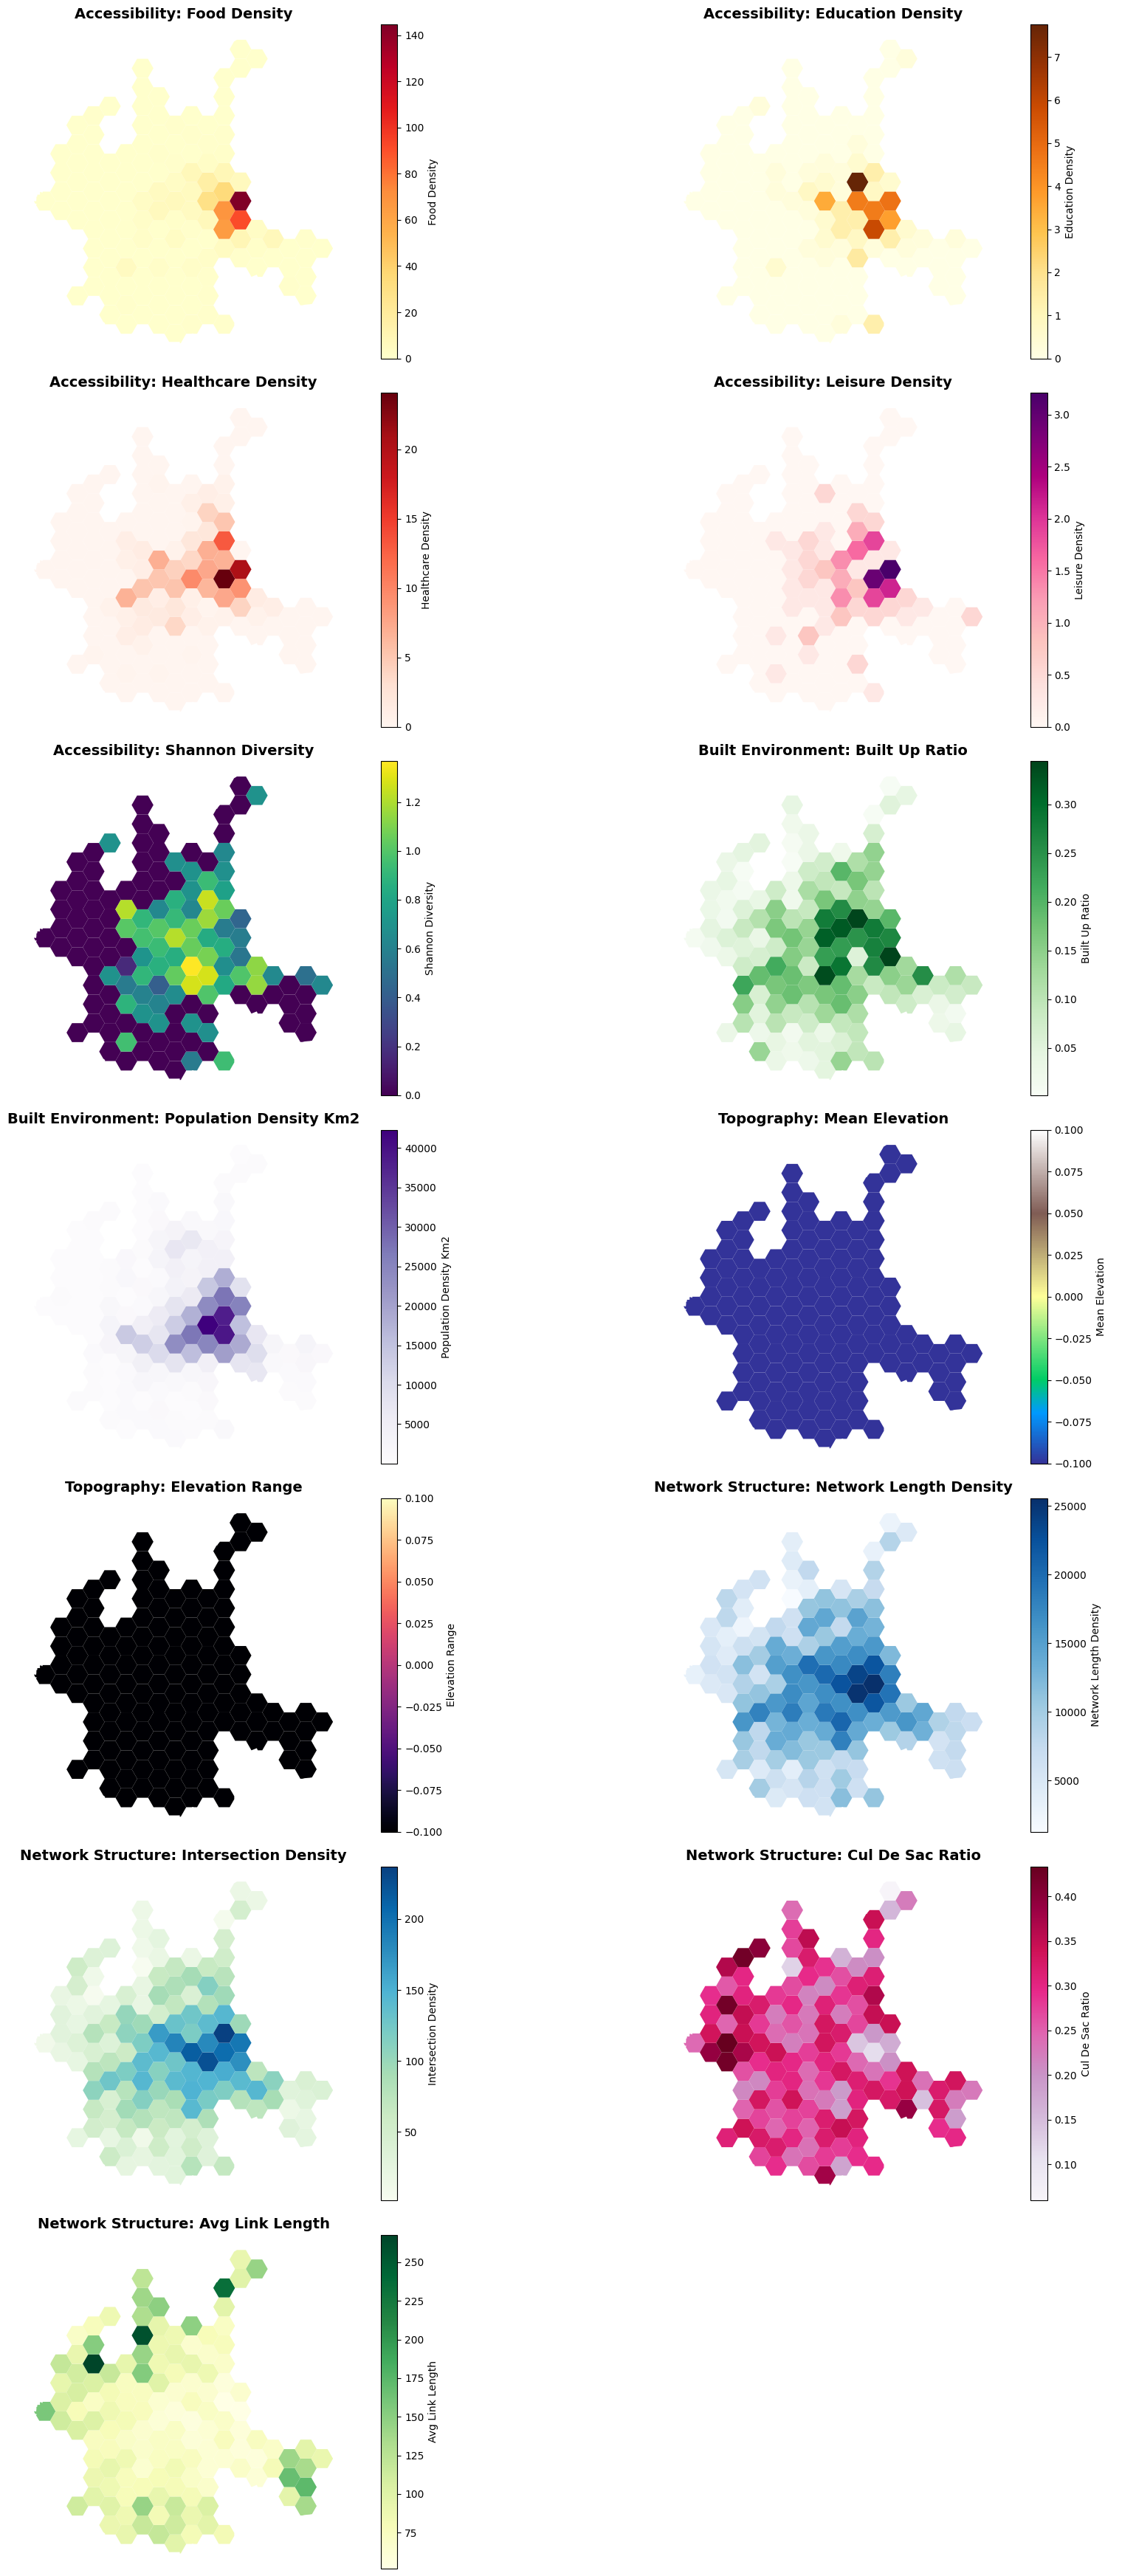

In [10]:
import matplotlib.pyplot as plt

# Group indicators by category for better visualization
categories = {
    'Accessibility': [
        ('food_density', 'YlOrRd'),
        ('education_density', 'YlOrBr'),
        ('healthcare_density', 'Reds'),
        ('leisure_density', 'RdPu'),
        ('shannon_diversity', 'viridis')
    ],
    'Built Environment': [
        ('built_up_ratio', 'Greens'),
        ('population_density_km2', 'Purples')
    ],
    'Topography': [
        ('mean_elevation', 'terrain'),
        ('elevation_range', 'magma')
    ],
    'Network Structure': [
        ('network_length_density', 'Blues'),
        ('intersection_density', 'GnBu'),
        ('cul_de_sac_ratio', 'PuRd'),
        ('avg_link_length', 'YlGn')
    ]
}

# Flatten for plotting while keeping category info
plot_list = []
for cat, items in categories.items():
    for col, cmap in items:
        plot_list.append((col, cat, cmap))

# Create subplots
n_plots = len(plot_list)
rows = (n_plots + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, (col, cat, cmap) in enumerate(plot_list):
    ax = axes[i]
    grid.plot(column=col, cmap=cmap, legend=True,
              legend_kwds={'label': col.replace('_', ' ').title(), 'orientation': "vertical"},
              ax=ax)
    ax.set_title(f"{cat}: {col.replace('_', ' ').title()}", fontsize=14, fontweight='bold')
    ax.set_axis_off()

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [11]:
# @title Step 11: Export Results

# Define output path
output_filename = "Jakarta_Urban_Indicators.gpkg"

# Export the grid GeoDataFrame to a GeoPackage file
grid.to_file(output_filename, driver="GPKG")

print(f"Successfully exported data to {output_filename}")

Successfully exported data to Jakarta_Urban_Indicators.gpkg


In [12]:
!pip freeze > colab_environment_snapshot.txt